# Maps and statistics of indexing results (2/3)

Read the `.fit` files of a map (1 grain index at a time: `####_g0.fit` by default) and plot maps and distributions of:
nb of indexed spots, mean pixel deviation, deviatoric strain, lattice parameters, orientation (Euler angles, crystal axes, misorientation)

**This notebook is part of the LaueTools package** (https://github.com/BM32ESRF/lauetools)

Author: J.-S. Micha, Last revision: Sept 2026. Tested with python 3.12 (jupyterlab, jupyterhub, VS Code)

| notebook | input | output |
|---|---|---|
| `1_index_refine.ipynb` | `.cor` files (peak search results) | `.fit` files (indexed spots, UB matrix, strain per grain) |
| `2_postprocess_maps.ipynb` | `.fit` files | maps & statistics: nb of spots, pixel deviation, strain, lattice parameters, orientation |
| `3_segmentation_grains.ipynb` | `.fit` files | grains (clusters of orientation), KAM, GROD, boundaries |

**All settings of an experiment are in a YAML configuration file**: copy `config_template.yaml` to `configs/my_experiment.yaml`, edit it and set `CONFIG` in the first code cell. The same file is used by the 3 notebooks. `configs/` contains examples of BM32 datasets (access to ESRF `/data` needed).

# SETTINGS

In [1]:
CONFIG = 'configs/a321220_MgO.yaml'   # configuration file of your experiment

FIT_FOLDER = None     # None: output fit_folder of the configuration file, or another folder of .fit files
GRAININDEX = None     # None: postprocess grainindex of the configuration file (0: ####_g0.fit files)
LIVE_PLOTS = False    # False: heavy multi-panel figures shown as static images (fast); True: interactive (zoom, hover values)

# IMPORTS

In [2]:
import os
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

try:
    import ipympl  # interactive plots (zoom, hover) in JupyterLab / VS Code
    %matplotlib widget
except ImportError:
    %matplotlib inline

import LaueTools.indexing_batch as IB
import LaueTools.generaltools as GT
import LaueTools.orientations as ORI
import LaueTools.orientationclustering as OC
import LaueTools.CrystalParameters as CP
import LaueTools.dict_LaueTools as DictLT
from LaueTools.fitfilereader import parsed_fitfile, parsed_fitfileseries
from LaueTools.LaueDataResultsPlots import (StrainMap, EulerAngles2D, LatticeParamsMap, PlotNumberIndexedSpots,
                                            PlotMeanDevPixel, StrainMapHistogram, LatticeParamsHistogram)

loading lauetools_config.json in  /mnt/multipath-shares/data/bm32/inhouse/SOFT/lauetoolsDEV/lauetools/LaueTools
No user materials.yaml found. Using default materials.yaml
-- warning: sklearn.metrics is not installed. For matchingrate.py module, it could be useful... but not necessary
-- WARNING: module Image or PIL is not installed, but only used for templateimagematching
loading readmccd.py
-- WARNING: Missing library libtiff, Please install: pylibtiff if you need open some tiff images. However, Fabio or PIL can do the job!
hostname = hpc6-03


# LOAD CONFIGURATION and .fit files

In [3]:
cfg = IB.load_config(CONFIG)
IB.print_config(cfg)

scan, post = cfg['scan'], cfg['postprocess']
mapdims, invmapdims = scan['mapdims'], scan['invmapdims']   # (fast, slow), (slow, fast)
motorfastaxis, motorslowaxis = scan['fast_motor'], scan['slow_motor']
fast_stepsize, slow_stepsize = scan['stepsizes']
xech = np.arange(mapdims[0]) * fast_stepsize
yech = np.arange(mapdims[1]) * slow_stepsize
prefix = scan['prefix']
key_material = cfg['material']['key_material']

fit_folder = Path(FIT_FOLDER) if FIT_FOLDER else cfg['output']['fit_folder']

fit_folder = '/data/visitor/a321220/bm32/20260915/PROCESSED_DATA/MH73_HT/MH73_HT_map_2D_p7_MgO_Fe_800/scan0001/fitfiles_MgO_6grains'
grainindex = post['grainindex'] if GRAININDEX is None else GRAININDEX
print(f'\n.fit files {prefix}{"#" * scan["nbdigits"]}_g{grainindex}.fit in {fit_folder}')
print(f'map (fast axis, slow axis): mapdims {mapdims}, motors ({motorfastaxis}, {motorslowaxis})')

---- a321220 MgO ----  (/gpfs/jazzy/data/bm32/inhouse/SOFT/lauetoolsDEV/lauetools/LaueTools/notebooks/indexation/configs/a321220_MgO.yaml)
.cor files:  /data/visitor/a321220/bm32/20260915/PROCESSED_DATA/MH73_HT/MH73_HT_map_2D_p7_MgO_Fe_800/scan0001/corfiles/eiger4m_####.cor
.fit files:  /data/visitor/a321220/bm32/20260915/PROCESSED_DATA/MH73_HT/MH73_HT_map_2D_p7_MgO_Fe_800/scan0001/fitfiles_MgO
map:         mapdims (fast, slow) = (51, 51), motors (yech, xech)
detector:    EIGER_4MCdTe, calibration /data/visitor/a321220/bm32/20260915/RAW_DATA/MH73/MH73_Ge/scan0001/calibGe001_MH73_RT_mardi.det
material:    MgO, energy 5-22 keV (indexing up to 19 keV), nbGrainstoFind = 3

.fit files eiger4m_####_g0.fit in /data/visitor/a321220/bm32/20260915/PROCESSED_DATA/MH73_HT/MH73_HT_map_2D_p7_MgO_Fe_800/scan0001/fitfiles_MgO_6grains
map (fast axis, slow axis): mapdims (51, 51), motors (yech, xech)


In [4]:
ffs0 = parsed_fitfileseries(folderpath=str(fit_folder), nb_cols=mapdims[0], nb_rows=mapdims[1],
                            prefix=prefix, suffix=f'_g{grainindex}.fit', use_multiprocessing=True,
                            nbdigits=scan['nbdigits'])
ffs0.fitfilefolder = fit_folder

Using 64 cpus.


Parsing progress:   0%|          | 0/2601 [00:00<?, ?it/s]

Done!


# QUALITY of indexing & refinement

## Nb of indexed spots (after refinement)

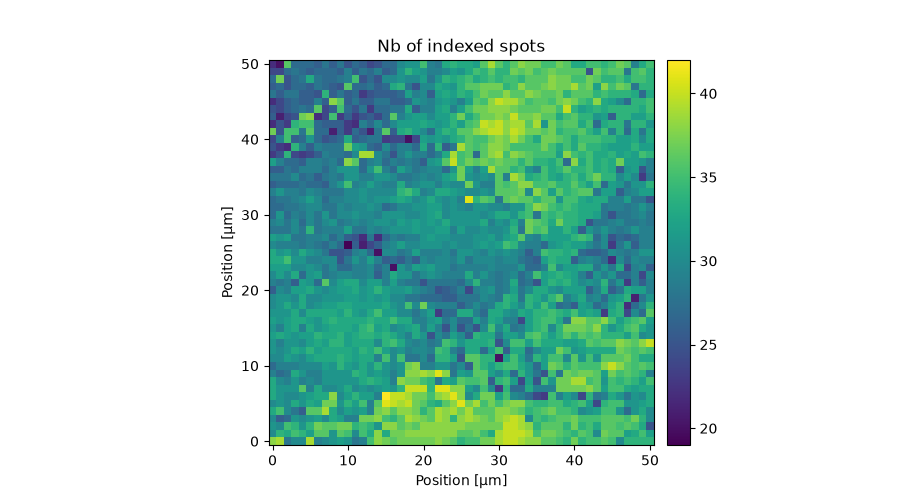

In [5]:
_, ax = PlotNumberIndexedSpots(indexed_fileseries=ffs0, size=(9, 5), origin='lower')
ax.format_coord = lambda x, y: GT.format_getimageindex_imshow(x, y, invmapdims)

## FILTER: mask of unreliable map points

masked (True) if too few indexed spots OR too large mean pixel deviation. Thresholds: section `postprocess` of the configuration file, or here. This mask (`combinedconds`) is used by all following maps.

1051 masked points / 2601


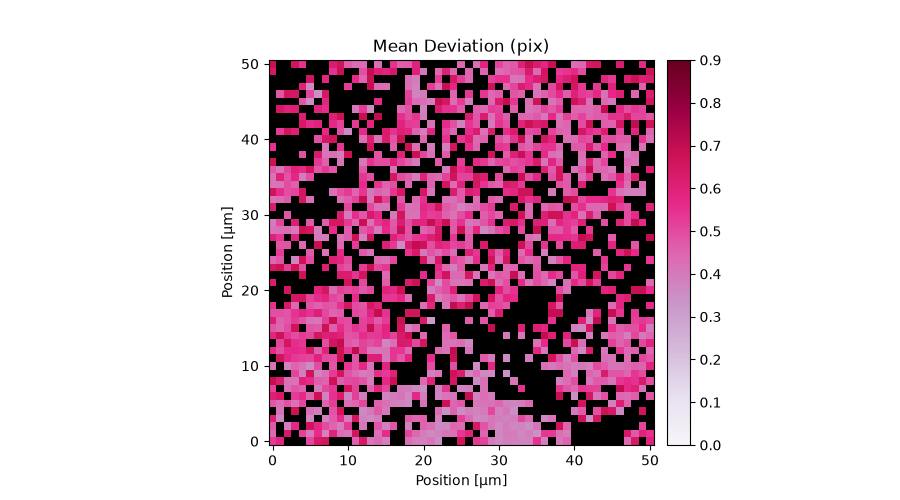

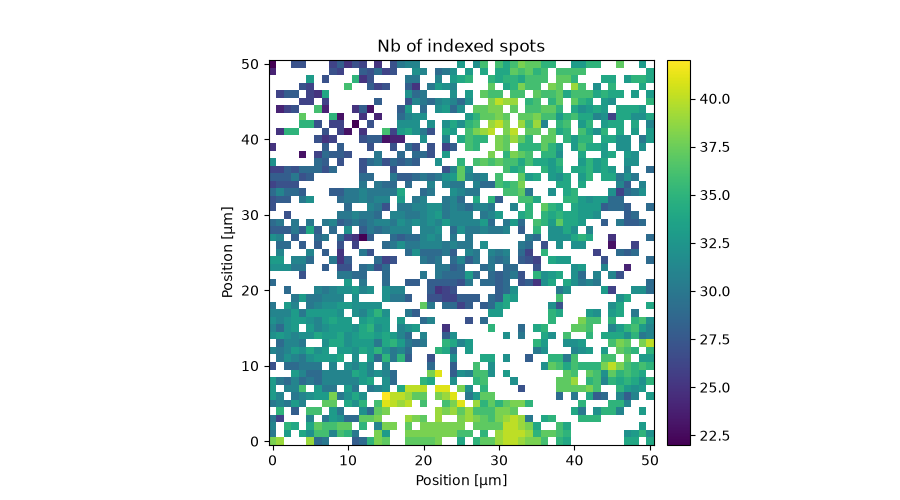

In [6]:
MinimumNbIndexedSpots = 20 #post['MinimumNbIndexedSpots']       # absolute nb of spots
LargestMeanPixelResidue = .7 #post['LargestMeanPixelResidue']   # pixel

maxdisplayedMeanPixDev = 0.9                                # pixel, color scale

masks = IB.quality_masks(ffs0, invmapdims, MinimumNbIndexedSpots, LargestMeanPixelResidue)
combinedconds = masks['combined']
print(f'{np.count_nonzero(combinedconds)} masked points / {combinedconds.size}')

pixdevcmap = mpl.colormaps['PuRd'].with_extremes(over='yellow', bad='black')
_, ax = PlotMeanDevPixel(indexed_fileseries=ffs0, size=(9, 5), origin='lower', maskingcondition=combinedconds,
                         norm=mpl.colors.Normalize(vmin=0, vmax=maxdisplayedMeanPixDev), cmap=pixdevcmap)
ax.format_coord = lambda x, y: GT.format_getimageindex_imshow(x, y, invmapdims)

_, ax = PlotNumberIndexedSpots(indexed_fileseries=ffs0, size=(9, 5), origin='lower', maskingcondition=combinedconds)
ax.format_coord = lambda x, y: GT.format_getimageindex_imshow(x, y, invmapdims)

# STRAIN

**Caution (cubic materials)**: in .fit files the UB matrix may be written in its 'lowest Euler angles' cubic representative while the crystal-frame strain and the lattice parameters remain in the refinement setting. Maps of crystal-frame quantities read directly from files (`ffs0`) may then mix settings from point to point (the sample-frame strain is not affected). See notebook 3: `OC.check_crystal_frame_settings()`, `OC.property_map()` and `OC.cluster_property_map()` give values in consistent crystal axes.

## strain map

xechstep 1.0
yechstep 1.0
deviatoric strain xx shape (51, 51)


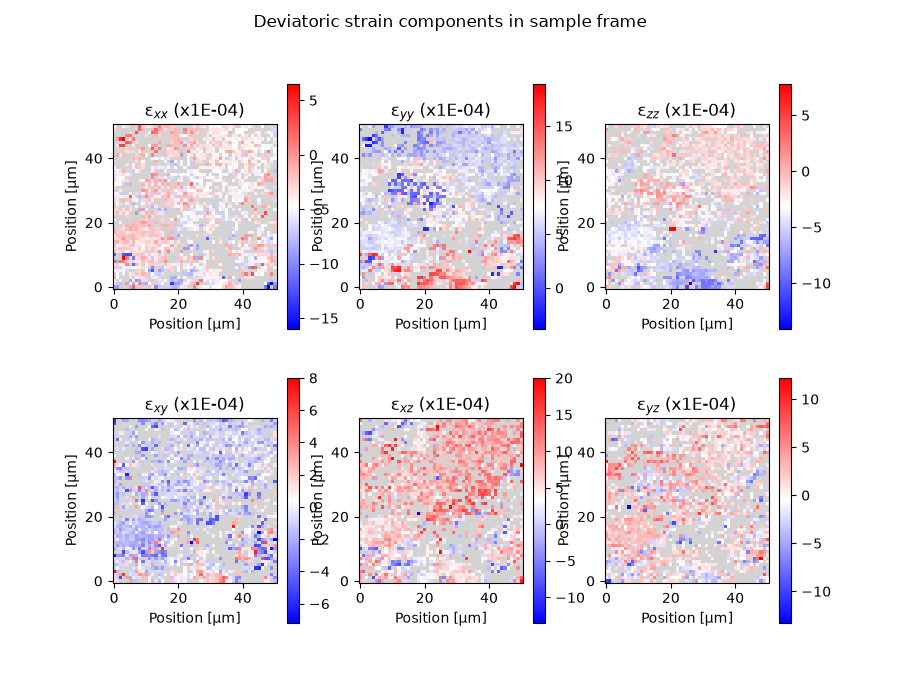

In [7]:
strain_frame = 'sample'   # 'sample' or 'crystal'
maxamplitudestrain = 5    # in 1e-4 units, used if norm is set below
straincmap = mpl.colormaps['bwr'].with_extremes(over='yellow', bad='lightgray', under='green')

fig, ax = StrainMap(xech=xech, yech=yech, indexed_fileseries=ffs0, frame=strain_frame,
                    multiplier=1e4, scale='other', vmin=None, vmax=None,
                    norm=None,   # mpl.colors.Normalize(vmin=-maxamplitudestrain, vmax=maxamplitudestrain)
                    size=(9, 7), cmap=straincmap, maskingcondition=combinedconds)
plt.show()

## strain components distributions (masked points excluded)

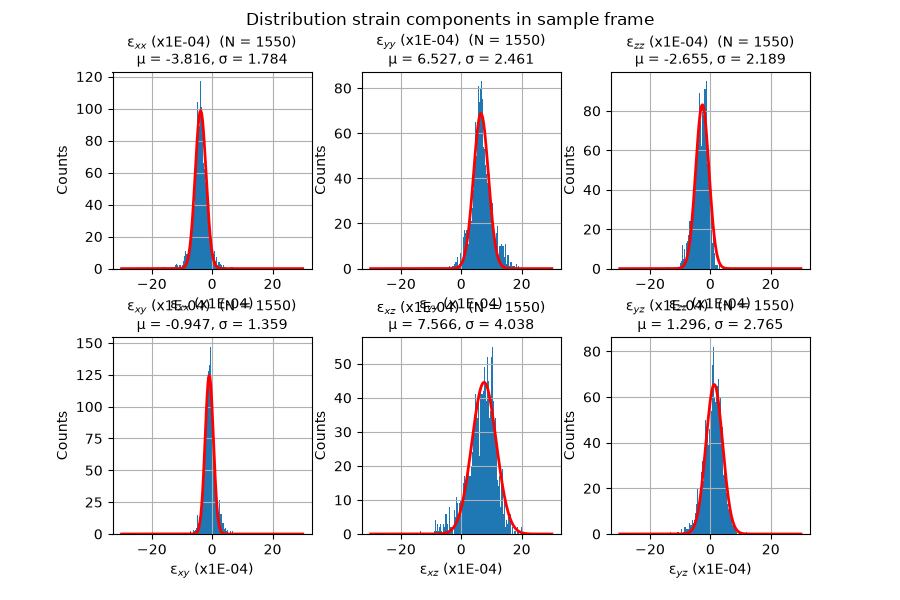

In [8]:
multiplier = 1e4   # 1e4: strain in 1e-4 units
fig, ax, fit_params = StrainMapHistogram(indexed_fileseries=ffs0, multiplier=multiplier,
                                         maskingcondition=combinedconds.ravel(), size=(9, 6), frame=strain_frame,
                                         bins=np.linspace(-30, 30, 200), fit=True)
[_ax.grid() for _ax in ax.ravel()]
plt.show()

## statistical report on strain values

In [9]:
GT.printgreen('Deviatoric strain distribution fit results:\ncomponent     mean      std')
print(f'         -- in {1. / multiplier:.0e} units in {strain_frame} frame --')
listcomponent = ['xx', 'yy', 'zz', 'xy', 'xz', 'yz'] if strain_frame == 'sample' else ['aa', 'bb', 'cc', 'ab', 'ac', 'bc']
for kk, comp in enumerate(listcomponent):
    amp, meanval, std = fit_params[kk]
    if kk == 3:
        print('-------')
    line = f'{comp}         {meanval:.3f}    {std:.3f}'
    if meanval > 1:
        GT.printred(line)
    elif meanval < -1:
        GT.pcolor(line, 'b')
    else:
        print(line)
fp = np.array(fit_params)
print('-------')
print(f'Largest absolute value: {np.amax(np.fabs(fp[:, 1])):.2f}')
print(f'Largest tensile (positive) value: {np.amax(fp[:, 1]):.2f}')
print(f'Largest compressive (negative) value: {np.amin(fp[:, 1]):.2f}')

Deviatoric strain distribution fit results:
component     mean      std
         -- in 1e-04 units in sample frame --
xx         -3.816    1.784
yy         6.527    2.461
zz         -2.655    2.189
-------
xy         -0.947    1.359
xz         7.566    4.038
yz         1.296    2.765
-------
Largest absolute value: 7.57
Largest tensile (positive) value: 7.57
Largest compressive (negative) value: -3.82


# LATTICE PARAMETERS

same mask as strain map. Color limits from percentiles of unmasked points (robust to outliers). See caution about cubic materials above.

In [15]:
fig.clear('all')

a     : constant = 4.21100 (fixed in refinement)
b     : mean 4.21201  std 0.00428  color limits [4.20294, 4.22130] (1-99%)
c     : mean 4.21242  std 0.00314  color limits [4.20394, 4.22062] (1-99%)
alpha : mean 90.00699  std 0.02623  color limits [89.93776, 90.07540] (1-99%)
beta  : mean 89.99384  std 0.03821  color limits [89.89619, 90.07906] (1-99%)
gamma : mean 90.01225  std 0.08939  color limits [89.83340, 90.15620] (1-99%)
xechstep 1.0
yechstep 1.0
alpha angle shape (51, 51)


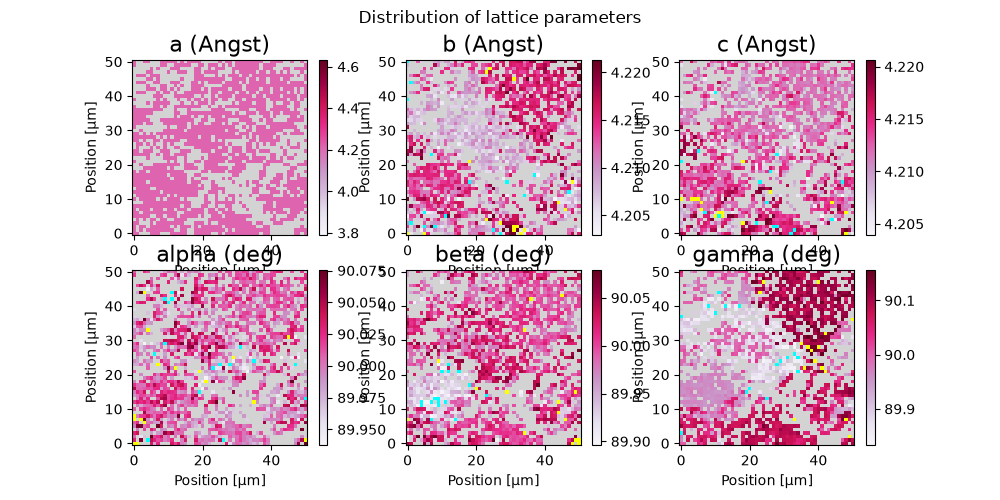

In [16]:
latcmap = mpl.colormaps['PuRd'].with_extremes(bad='lightgray', over='yellow', under='cyan')
latmask = combinedconds

lowpercentile, highpercentile = 1, 99
latvlimits = []
for name in ['a', 'b', 'c', 'alpha', 'beta', 'gamma']:
    values = getattr(ffs0, name).reshape(invmapdims)
    values = values[np.logical_not(latmask) & np.isfinite(values)]
    vmin, vmax = np.percentile(values, [lowpercentile, highpercentile])
    if np.isclose(vmin, vmax):
        # e.g. a is kept fixed (reference value) by the deviatoric strain refinement
        print(f'{name:6s}: constant = {vmin:.5f} (fixed in refinement)')
        latvlimits.append((None, None))
        continue
    print(f'{name:6s}: mean {np.mean(values):.5f}  std {np.std(values):.5f}  '
          f'color limits [{vmin:.5f}, {vmax:.5f}] ({lowpercentile}-{highpercentile}%)')
    latvlimits.append((vmin, vmax))

fig, ax = LatticeParamsMap(xech=xech, yech=yech, indexed_fileseries=ffs0, scale='default',
                           vlimits=latvlimits, size=(10, 5), cmap=latcmap, maskingcondition=latmask)
plt.show()

## lattice parameters distributions

histogram range: `percentile_range` of each parameter, or give `bins` as a list of 6 arrays. Distributions may be multimodal (one peak per grain): compare gaussian fit with plain mean and std.

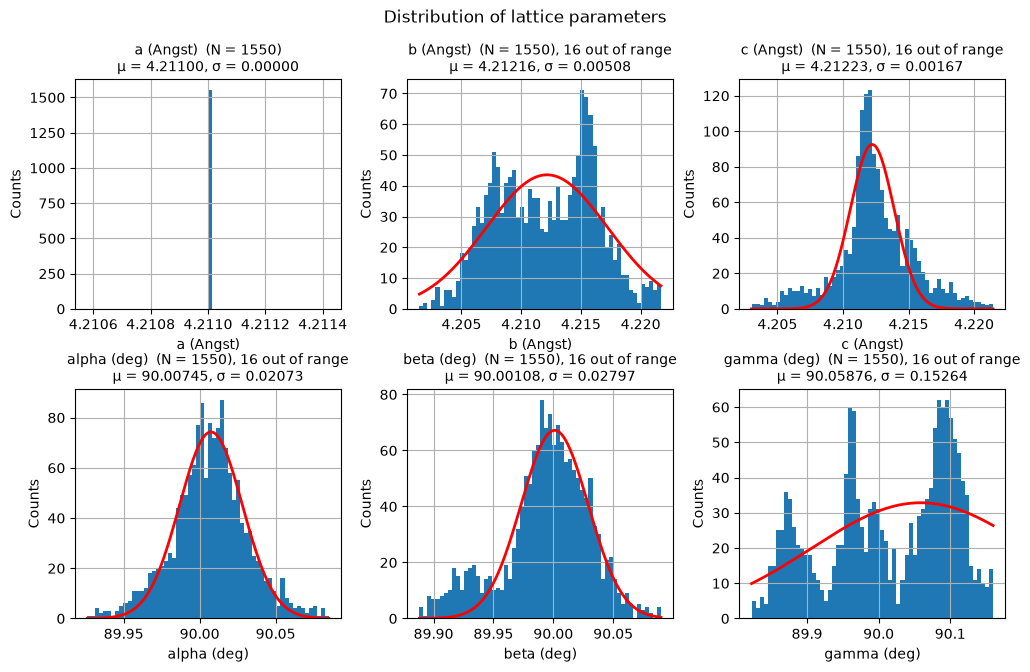

Lattice parameters distribution (unmasked points)
parameter    fit mean     fit std        mean          std
a             4.21100     0.00000      4.21100      0.00000
b             4.21216     0.00508      4.21201      0.00428
c             4.21223     0.00167      4.21242      0.00314
alpha        90.00745     0.02073     90.00699      0.02623
beta         90.00108     0.02797     89.99384      0.03821
gamma        90.05876     0.15264     90.01225      0.08939


In [11]:
fig, ax, latfit_params = LatticeParamsHistogram(indexed_fileseries=ffs0, maskingcondition=latmask, size=(12, 7),
                                                bins=60, percentile_range=(0.5, 99.5), fit=True)
[_ax.grid() for _ax in ax.ravel()]
IB.show_figure(fig, live=LIVE_PLOTS)

GT.printgreen('Lattice parameters distribution (unmasked points)\n'
              'parameter    fit mean     fit std        mean          std')
for name, (amp, meanval, std) in zip(['a', 'b', 'c', 'alpha', 'beta', 'gamma'], latfit_params):
    values = getattr(ffs0, name).reshape(invmapdims)
    values = values[np.logical_not(latmask) & np.isfinite(values)]
    print(f'{name:8s} {meanval:12.5f} {std:11.5f} {np.mean(values):12.5f} {np.std(values):12.5f}')

# ORIENTATION

## Euler angles

xechstep 1.0
yechstep 1.0


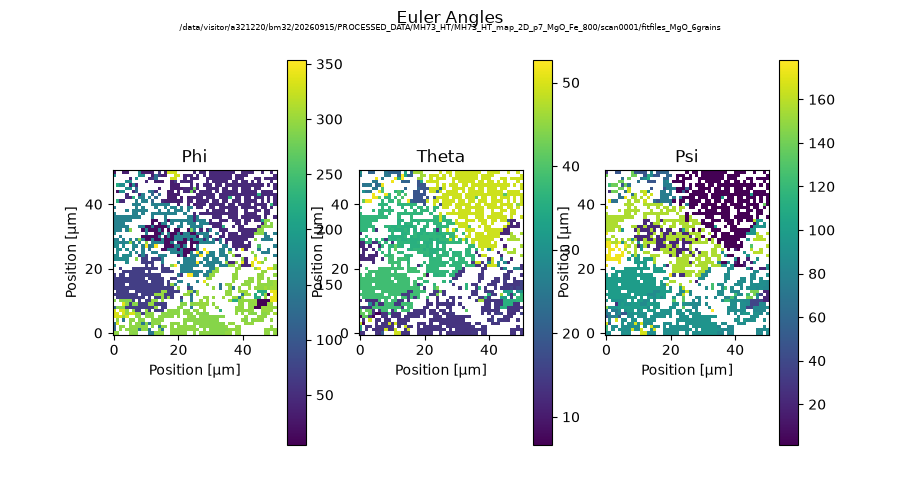

Statistics on Euler angles -------------
For Phi: mean 149.78 deg     std 107.72 deg
For Theta: mean 33.06 deg     std 13.87 deg
For Psi: mean 80.02 deg     std 57.02 deg


In [17]:
phi, theta, psi = EulerAngles2D(xech=xech, yech=yech, indexed_fileseries=ffs0, maskingcondition=combinedconds,
                                size=(9, 5))
plt.show()

print('Statistics on Euler angles -------------')
for data, name in zip((phi, theta, psi), ('Phi', 'Theta', 'Psi')):
    print(f'For {name}: mean {np.nanmean(data):.2f} deg     std {np.nanstd(data):.2f} deg')

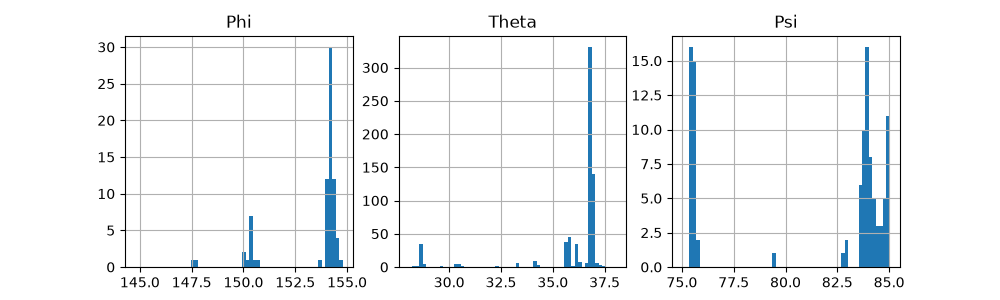

In [19]:
nbbins = 60
halfranges = (5, 5, 5)   # deg, histogram range around the mean value of phi, theta, psi

fighisteuler, axhisteuler = plt.subplots(1, 3, figsize=(10, 3))
fighisteuler.subplots_adjust(hspace=0.25, wspace=0.2)
for axis, data, title, delta in zip(axhisteuler, (phi, theta, psi), ('Phi', 'Theta', 'Psi'), halfranges):
    mean = np.nanmean(data)
    axis.hist(np.ravel(data), range=(mean - delta, mean + delta), bins=nbbins)
    axis.set_title(title)
    axis.grid()
plt.show()

## UB matrix of a map point

In [21]:
# image_ix, image_iy = 6, 0   # position (index) along fast and slow axes
# i_image = IB.getimageindex_fromxyech(image_ix, image_iy, invmapdims)
# print(f'For image #{i_image}, orientation matrix UB:\n', ffs0.UB[i_image].tolist())

# fitfile = fit_folder / f'{prefix}{i_image:0{scan["nbdigits"]}d}_g{grainindex}.fit'
# if fitfile.exists():
#     ffile = parsed_fitfile(str(fitfile), verbose=0)
#     print('nb of indexed spots', ffile.NumberOfIndexedSpots, ', mean pixel deviation', ffile.MeanDevPixel)

## inverse pole figure (IPF) maps

Color of the crystal direction parallel to the sample axes X, Y, Z (Z = normal to the sample surface), brought by symmetry into the standard triangle of the Laue group. Color key (right): stereographic projection of the standard triangle with red, green, blue corners (TSL convention, as in EBSD softwares), e.g. [001], [101], [111] for cubic crystals. Black: masked (see FILTER) or missing points.

- sample frame (LaueTools, `LaueGeometry.fromlab_tosample()`): lab frame (x // incident beam, z towards the detector, y = z ^ x) rotated by `SAMPLE_TILT` (40° at BM32) around y:
  Z = normal to the sample surface, X = in the surface plane, tilted by 40° from the incident beam, Y = y lab (horizontal, perpendicular to the beam).
  It is the frame of the sample-frame strain of the .fit files (labelled 'sample2' in the .fit files) and of the STRAIN section.
  On BM32 (`CrystalParameters.strain_from_crystal_to_sample_frame2()`): xech = -Y, yech = X, zech = Z
- Laue group: `postprocess: laue_group` of the configuration file: `auto` (from lattice parameters of `key_material`), `m-3m`, `6/mmm`, `-3m1` (trigonal in hexagonal axes: Al2O3, quartz ...), `4/mmm`, `mmm`
- UB matrices are orthonormalized (polar decomposition): colors do not depend on the deviatoric strain
- code: module `LaueTools/ipfmap.py`

Laue group: m-3m


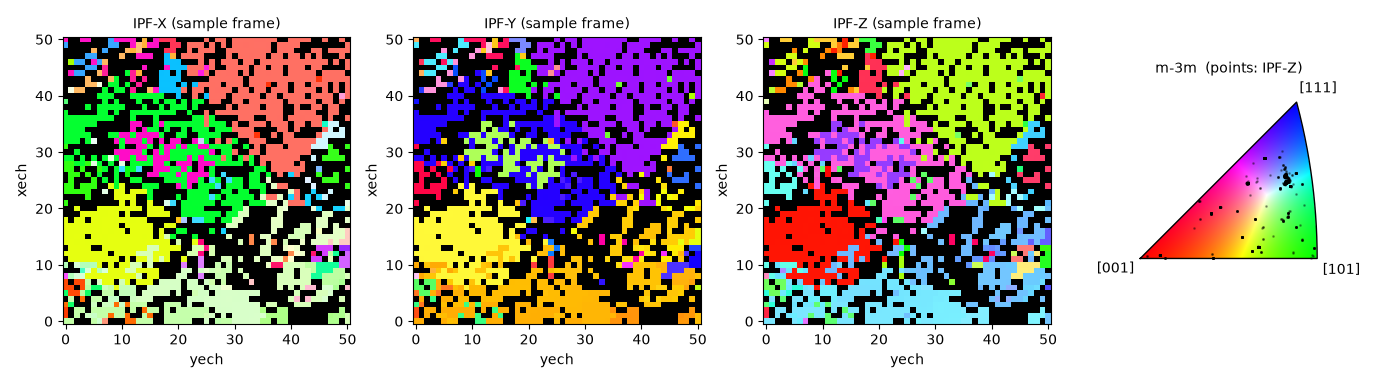

In [26]:
fig.clear('all')
import LaueTools.ipfmap as IPF

SAMPLE_TILT = 40   # deg, inclination of the sample surface (BM32)
laue_group = post['laue_group']
if laue_group == 'auto':
    laue_group = IPF.laue_group_of_material(key_material, cfg['material']['mymaterials'])
print('Laue group:', laue_group)

# ipf_rgb: {'x': rgb map (nb rows, nb cols, 3), 'y': ..., 'z': ...}
fig, axes, ipf_rgb = IPF.plot_ipf_maps(ffs0.UB, invmapdims, laue_group, sample_axes=('x', 'y', 'z'),
                                       anglesample=SAMPLE_TILT, mask=combinedconds,
                                       xlabel=motorfastaxis, ylabel=motorslowaxis)
plt.show()

### inverse pole figures (measured directions in the standard triangle)

each point: crystal direction parallel to a sample axis at one (unmasked) map point

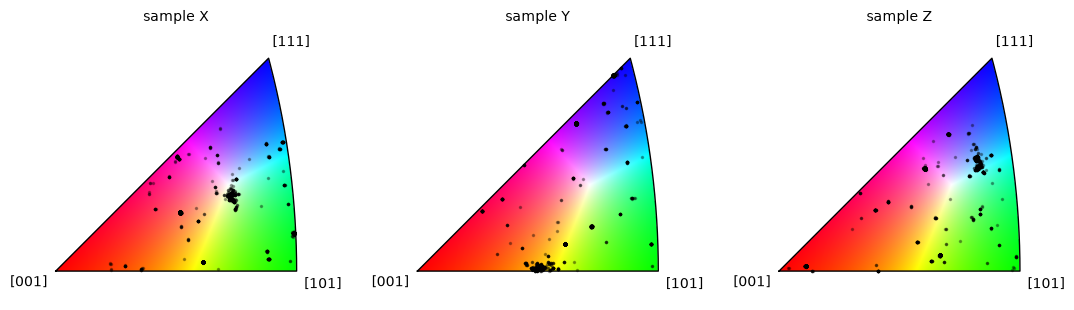

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
for ax, sample_axis in zip(axes, ('x', 'y', 'z')):
    directions = IPF.sample_directions_in_crystal(ffs0.UB[:mapdims[0] * mapdims[1]], sample_axis, SAMPLE_TILT)
    IPF.plot_ipf_key(laue_group, ax=ax, directions=directions[~combinedconds.ravel()], markersize=3, alpha=0.3,
                     title=f'sample {sample_axis.upper()}')
fig.tight_layout()
IB.show_figure(fig, live=LIVE_PLOTS)

## crystal axes directions

|cos| of the angle between the reciprocal axes a*, b*, c* and the sample axes x, y, z (sample tilted by `SAMPLE_TILT` deg around y, 40 deg at BM32)

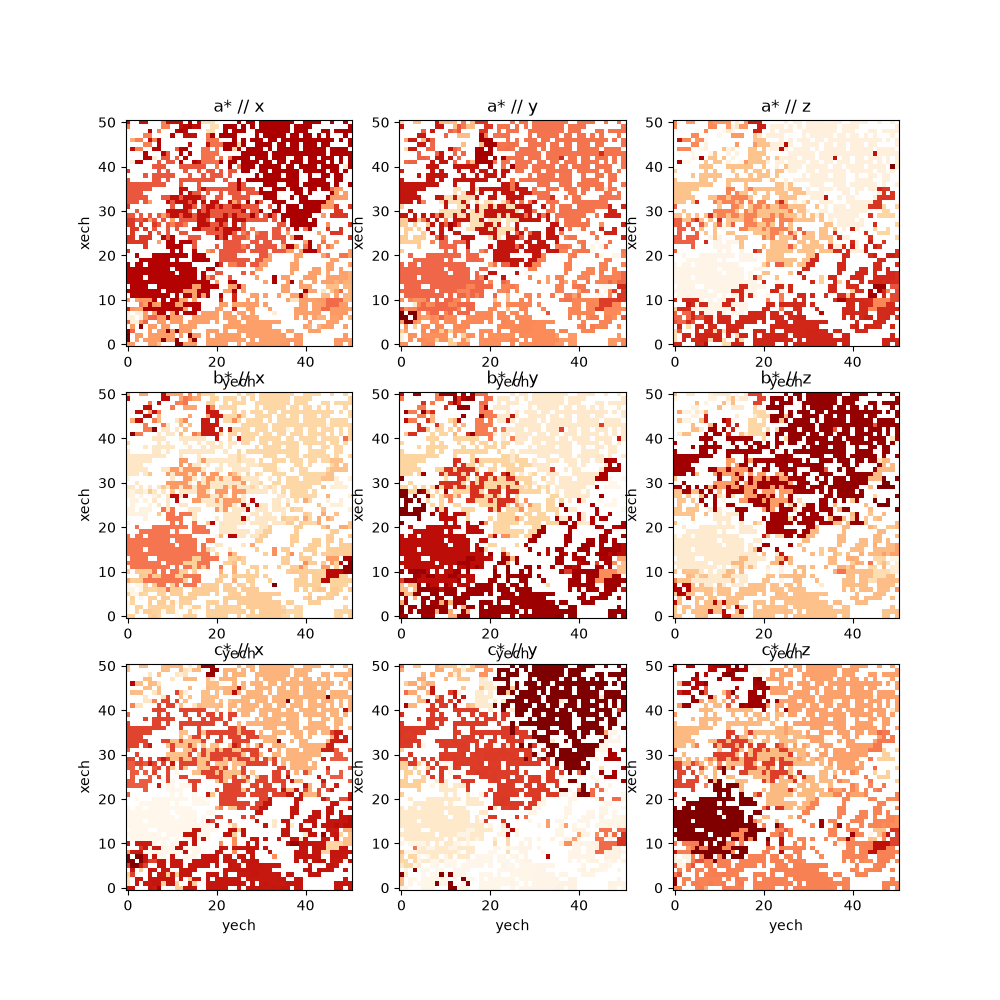

In [28]:
SAMPLE_TILT = 40   # deg
B0matrix = next(b0 for b0 in ffs0.B0 if np.all(np.isfinite(b0)))   # same structure for all points
samplerot = GT.matRot([0, 1, 0], -SAMPLE_TILT)
tensortitles = ['a* // x', 'a* // y', 'a* // z', 'b* // x', 'b* // y', 'b* // z', 'c* // x', 'c* // y', 'c* // z']
crystal_axes = np.eye(3)
sample_axes = np.eye(3)

tab_cmps = []
with np.errstate(invalid='ignore'):   # NaN for missing .fit files
    for crystal_axis in crystal_axes:
        qdirs = np.einsum('nij,jk,k->ni', ffs0.UB, B0matrix, crystal_axis)   # directions in lab frame
        qdirs /= np.linalg.norm(qdirs, axis=1)[:, None]
        for sample_axis in sample_axes:
            cosval = np.abs(qdirs @ samplerot.dot(sample_axis))
            tab_cmps.append(np.where(np.isfinite(cosval), cosval, 1.).reshape(invmapdims))

fig, ax = plt.subplots(3, 3, figsize=(10, 10))
for axidx, data, title in zip(np.ndindex(ax.shape), tab_cmps, tensortitles):
    ax[axidx].imshow(np.where(np.logical_not(combinedconds), data, np.nan), cmap='OrRd', origin='lower')
    ax[axidx].set_title(title)
    ax[axidx].format_coord = lambda x, y: GT.format_getimageindex_imshow(x, y, invmapdims)
    ax[axidx].set_xlabel(motorfastaxis)
    ax[axidx].set_ylabel(motorslowaxis)
plt.show()

## MISORIENTATION angle (deg) to a reference map point

crystal symmetry taken into account for cubic materials (section `postprocess: symmetry` of the configuration file)

reference image 1936, symmetry cubic, UB ref [[0.720995117, 0.697867877, -0.017556364], [-0.44466869, 0.479788366, 0.754887536], [0.53181404, -0.531824955, 0.651901503]]


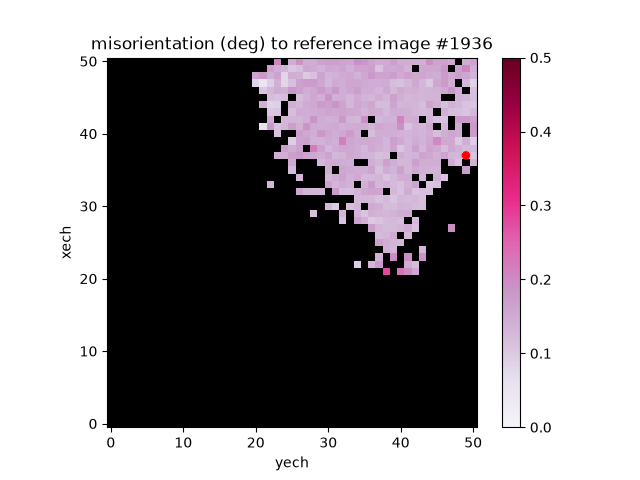

In [33]:
i_ref = post['reference_image_index']
i_ref = 1936
if i_ref is None:   # default: first well indexed point
    i_ref = int(np.flatnonzero(~combinedconds.ravel())[0])

symmetry = post['symmetry']
if symmetry == 'auto':
    symmetry = 'cubic' if CP.hasCubicSymmetry(key_material, cfg['material']['mymaterials'] or DictLT.dict_Materials) else None
symops = OC.get_symmetry_operators(symmetry)   # None: raw angles

UB0 = ffs0.UB[i_ref]
print(f'reference image {i_ref}, symmetry {symmetry}, UB ref', UB0.tolist())
refrot = OC.orthonormalize(UB0)
rots = OC.orthonormalize(ffs0.UB[:mapdims[0] * mapdims[1]])   # NaN for missing images
AngleDev, _ = OC.misorientation(np.broadcast_to(refrot, rots.shape), rots, symops)

oricmap = mpl.colormaps['PuRd'].with_extremes(over='black', bad='black')
fig, ax = plt.subplots()
im = ax.imshow(AngleDev.reshape(invmapdims), vmin=0, vmax=.5, cmap=oricmap, origin='lower')
ax.set_title(f'misorientation (deg) to reference image #{i_ref}')
ax.add_patch(plt.Circle((i_ref % mapdims[0], i_ref // mapdims[0]), 0.5, color='r'))
fig.colorbar(im)
ax.set_xlabel(motorfastaxis)
ax.set_ylabel(motorslowaxis)
ax.format_coord = lambda x, y: GT.format_getimageindex_imshow(x, y, invmapdims)
plt.show()

**Next step:** `3_segmentation_grains.ipynb` (grains, KAM, GROD, boundaries) with the same `CONFIG`